# VAE for MNIST

In [1]:
import random, sys
from pathlib import Path
from typing import Callable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from sklearn.manifold import TSNE
import torch
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

## 參數設定

In [2]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑
BATCH_SIZE = 256  # 批量
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入 MNIST 手寫阿拉伯數字資料

In [3]:
train_ds = datasets.MNIST(PATH_DATASETS, train=True, download=True)
test_ds = datasets.MNIST(PATH_DATASETS, train=False, download=True)

## 顯示 MNIST 圖像

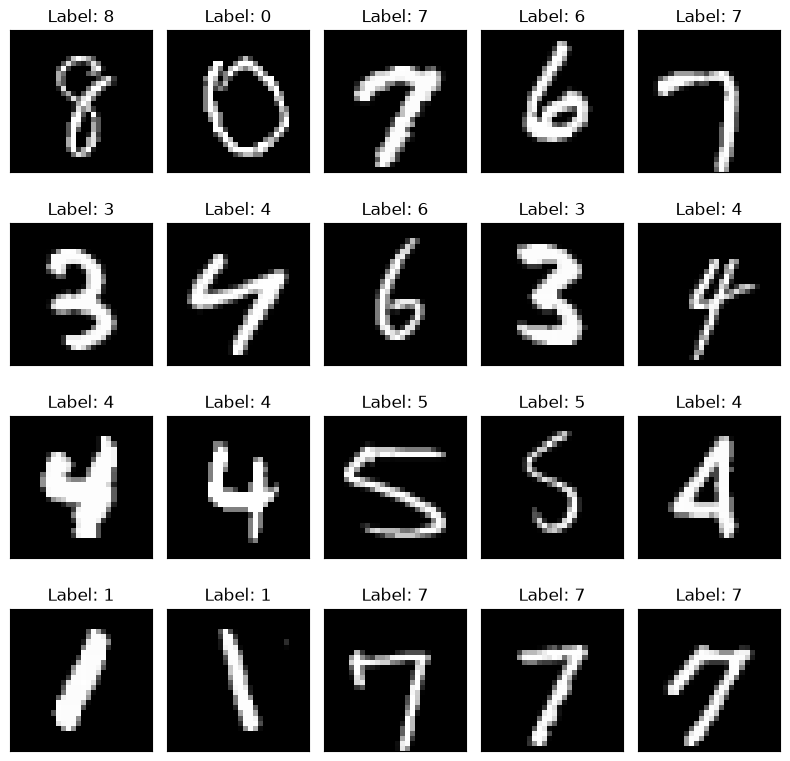

In [4]:
fig, axs = plt.subplots(4, 5, figsize=(8, 8))
for ax in axs.flatten():
    # 隨機抽樣
    img, label = random.choice(train_ds)
    ax.imshow(np.array(img), cmap='gist_gray')
    ax.set_title('Label: %d' % label)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()

## 建立 DataLoader

In [5]:
# 轉為張量
train_ds.transform = transforms.ToTensor()
test_ds.transform = transforms.ToTensor()

# 切割20%訓練資料作為驗證資料
m = len(train_ds)  # 總筆數
train_data, val_data = random_split(train_ds, [int(m - m * 0.2), int(m * 0.2)])

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE)
valid_loader = DataLoader(val_data, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=True)

## 定義模型，含 Encoder and Decoder 

In [6]:
class Encoder(nn.Module):
    def __init__(self, encoded_space_dim: int, fc2_input_dim: int) -> None:
        super().__init__()

        # Convolution
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, 3, stride=2, padding=1),
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=0),
            nn.ReLU(True),
        )

        self.flatten = nn.Flatten(start_dim=1)

        self.encoder_lin = nn.Sequential(
            nn.Linear(3 * 3 * 32, 128),
        )

        self.encFC1 = nn.Linear(128, encoded_space_dim)
        self.encFC2 = nn.Linear(128, encoded_space_dim)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.encoder_cnn(x)
        x = self.flatten(x)
        x = self.encoder_lin(x)
        mu = self.encFC1(x)
        logVar = self.encFC2(x)
        return mu, logVar

##  定義抽樣函數

In [7]:
def resample(mu: torch.Tensor, logVar: torch.Tensor) -> torch.Tensor:
    std = torch.exp(logVar / 2)
    eps = torch.randn_like(std)  # N(0, 1) 抽樣
    return mu + std * eps

##  定義解碼器

In [8]:
class Decoder(nn.Module):
    def __init__(self, encoded_space_dim: int, fc2_input_dim: int) -> None:
        super().__init__()

        self.decoder_lin = nn.Sequential(
            nn.Linear(encoded_space_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 3 * 3 * 32),
            nn.ReLU(True),
        )

        self.unflatten = nn.Unflatten(dim=1, unflattened_size=(32, 3, 3))

        self.decoder_conv = nn.Sequential(
            # 反卷積
            nn.ConvTranspose2d(32, 16, 3, stride=2, output_padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(True),
            nn.ConvTranspose2d(8, 1, 3, stride=2, padding=1, output_padding=1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.decoder_lin(x)
        x = self.unflatten(x)
        x = self.decoder_conv(x)
        x = torch.sigmoid(x)
        return x

## 建立模型

In [9]:
# 固定隨機亂數種子，以利掌握執行結果
torch.manual_seed(0)

# encoder 輸出個數、decoder 輸入個數
d = 4
encoder = Encoder(encoded_space_dim=d, fc2_input_dim=128).to(device)
decoder = Decoder(encoded_space_dim=d, fc2_input_dim=128).to(device)

## 定義損失函數及優化器

In [10]:
# KL divergence
def loss_fn(out: torch.Tensor, imgs: torch.Tensor, mu: torch.Tensor, logVar: torch.Tensor) -> torch.Tensor:
    kl_divergence = 0.5 * torch.sum(1 + logVar - mu.pow(2) - logVar.exp())
    return F.binary_cross_entropy(out, imgs, size_average=False) - kl_divergence


lr = 0.001  # Learning rate

params_to_optimize = [
    {'params': encoder.parameters()},
    {'params': decoder.parameters()},
]

optimizer = optim.Adam(params_to_optimize, lr=lr)

## 定義加雜訊(Noise)的函數

In [11]:
def add_noise(inputs: torch.Tensor, noise_factor: float = 0.3) -> torch.Tensor:
    noise = inputs + torch.randn_like(inputs) * noise_factor
    noise = torch.clip(noise, 0.0, 1.0)
    return noise

## 定義訓練函數

In [12]:
def train_epoch_den(
    encoder: Encoder,
    decoder: Decoder,
    device: str,
    dataloader: DataLoader,
    loss_fn: Callable[[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor],
    optimizer: optim.Optimizer,
    noise_factor: float = 0.3,
) -> float:
    # 指定為訓練階段
    encoder.train()
    decoder.train()
    train_loss = []
    # 訓練
    image_batch: torch.Tensor
    for image_batch, _ in dataloader:
        # 加雜訊
        image_noisy = add_noise(image_batch, noise_factor)
        image_noisy = image_noisy.to(device)
        # 編碼
        mu, logVar = encoder(image_noisy)
        encoded_data = resample(mu, logVar)
        # 解碼
        decoded_data: torch.Tensor = decoder(encoded_data)
        # 計算損失
        loss = loss_fn(decoded_data, image_noisy, mu, logVar)

        # 反向傳導
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # print(f'損失：{loss.data}')
        train_loss.append(loss.detach().cpu().numpy())

    return float(np.mean(train_loss))

## 定義測試函數

In [13]:
def test_epoch_den(
    encoder: Encoder,
    decoder: Decoder,
    device: str,
    dataloader: DataLoader,
    loss_fn: Callable[[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor],
    noise_factor: float = 0.3,
) -> torch.Tensor:
    # 指定為評估階段
    encoder.eval()
    decoder.eval()
    val_loss = torch.tensor(0.0)
    with torch.no_grad():  # No need to track the gradients
        conc_out = []
        conc_label = []
        image_batch: torch.Tensor
        for image_batch, _ in dataloader:
            # 加雜訊
            image_noisy = add_noise(image_batch, noise_factor)
            image_noisy = image_noisy.to(device)
            # 編碼
            mu, logVar = encoder(image_noisy)
            encoded_data = resample(mu, logVar)
            # 解碼
            decoded_data: torch.Tensor = decoder(encoded_data)
            # 輸出存入 conc_out 變數
            conc_out.append(decoded_data.cpu())
            conc_label.append(image_batch.cpu())
            val_loss += loss_fn(decoded_data, image_batch.to(device), mu, logVar).cpu()
        # 合併
        conc_out = torch.cat(conc_out)
        conc_label = torch.cat(conc_label)
        # 驗證資料的損失
    return val_loss.data

## 定義重建圖像的函數

In [14]:
# fix 中文亂碼
plt.rcParams['font.sans-serif'] = ['Zhuque Fangsong (technical preview)']
plt.rcParams['axes.unicode_minus'] = False


def plot_ae_outputs_den(epoch: int, encoder: Encoder, decoder: Decoder, n: int = 5, noise_factor: float = 0.3) -> None:
    plt.figure(figsize=(10, 4.5))
    for i in range(n):
        ax = plt.subplot(3 if epoch == 0 else 1, n, i + 1)
        img = test_ds[i][0].unsqueeze(0)
        image_noisy = add_noise(img, noise_factor)
        image_noisy = image_noisy.to(device)

        encoder.eval()
        decoder.eval()

        with torch.no_grad():
            rec_img: torch.Tensor = decoder(resample(*encoder(image_noisy)))

        if epoch == 0:
            plt.imshow(img.cpu().squeeze().numpy(), cmap='gist_gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == n // 2:
                ax.set_title('原圖')
            ax = plt.subplot(3, n, i + 1 + n)
            plt.imshow(image_noisy.cpu().squeeze().numpy(), cmap='gist_gray')
            ax.get_xaxis().set_visible(False)
            ax.get_yaxis().set_visible(False)
            if i == n // 2:
                ax.set_title('加雜訊')

        if epoch == 0:
            ax = plt.subplot(3, n, i + 1 + n + n)
        else:
            ax = plt.subplot(1, n, i + 1)
        plt.imshow(rec_img.cpu().squeeze().numpy(), cmap='gist_gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        if epoch == 0 and i == n // 2:
            ax.set_title('重建圖像')
    plt.subplots_adjust(left=0.1, bottom=0.1, right=0.7, top=0.9, wspace=0.3, hspace=0.3)
    plt.show()

## 訓練

/Users/rikenmi/Work/study/python/PyTorch_Book/.venv/lib/python3.12/site-packages/torch/nn/_reduction.py:60: UserWarning: size_average and reduce args will be deprecated, please use reduction='sum' instead.
  return get_enum(legacy_get_string(size_average, reduce, emit_warning))


EPOCH 1/50 	 訓練損失：125977.578 	 驗證損失： 3865915.500


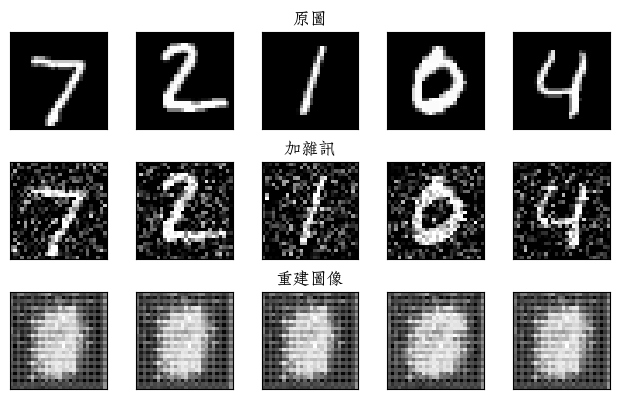

EPOCH 2/50 	 訓練損失：97840.797 	 驗證損失： 2942040.750


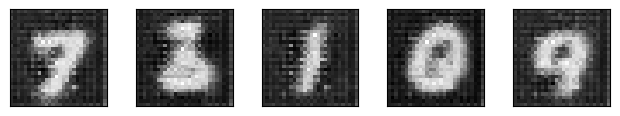

EPOCH 3/50 	 訓練損失：92846.828 	 驗證損失： 2710592.750


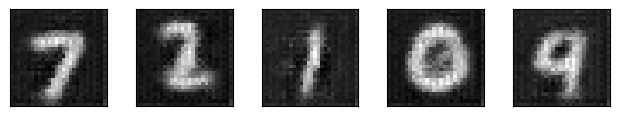

EPOCH 4/50 	 訓練損失：91246.055 	 驗證損失： 2594291.250


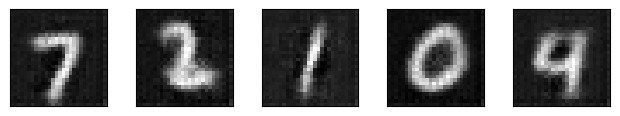

EPOCH 5/50 	 訓練損失：90507.320 	 驗證損失： 2560076.250


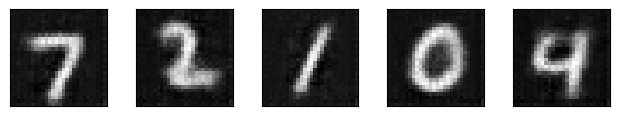

EPOCH 6/50 	 訓練損失：90099.172 	 驗證損失： 2526692.750


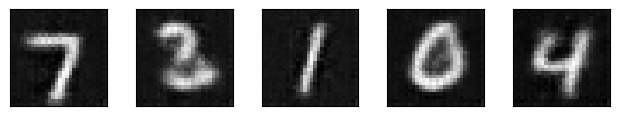

EPOCH 7/50 	 訓練損失：89885.086 	 驗證損失： 2510578.500


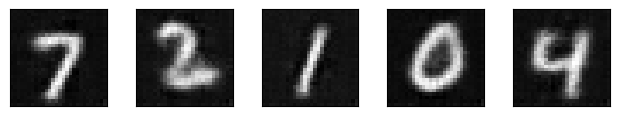

EPOCH 8/50 	 訓練損失：89720.875 	 驗證損失： 2500821.250


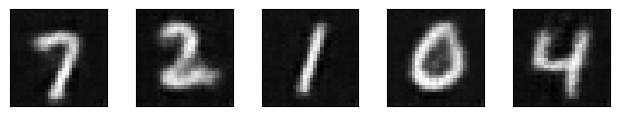

EPOCH 9/50 	 訓練損失：89641.297 	 驗證損失： 2487762.250


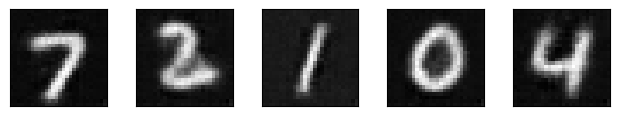

EPOCH 10/50 	 訓練損失：89520.141 	 驗證損失： 2484739.500


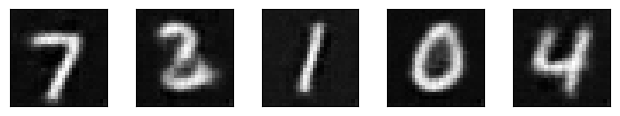

EPOCH 11/50 	 訓練損失：89443.062 	 驗證損失： 2478505.750


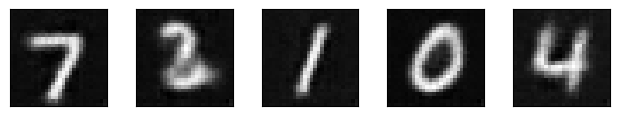

EPOCH 12/50 	 訓練損失：89390.062 	 驗證損失： 2471801.500


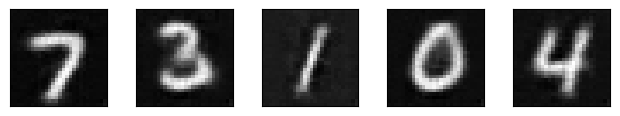

EPOCH 13/50 	 訓練損失：89365.039 	 驗證損失： 2465314.000


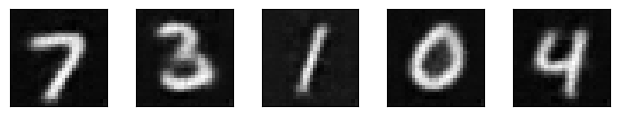

EPOCH 14/50 	 訓練損失：89307.234 	 驗證損失： 2457052.750


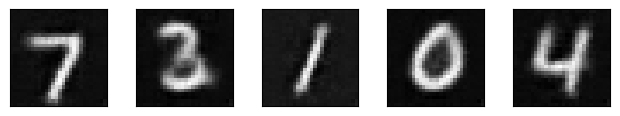

EPOCH 15/50 	 訓練損失：89258.992 	 驗證損失： 2461087.500


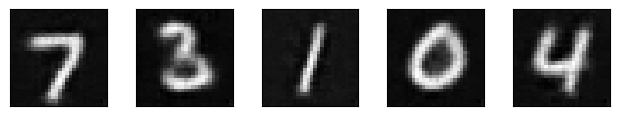

EPOCH 16/50 	 訓練損失：89228.125 	 驗證損失： 2459097.500


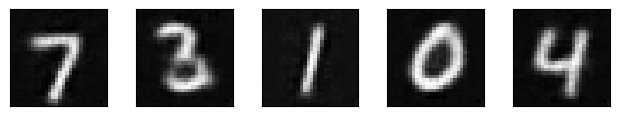

EPOCH 17/50 	 訓練損失：89185.383 	 驗證損失： 2454908.250


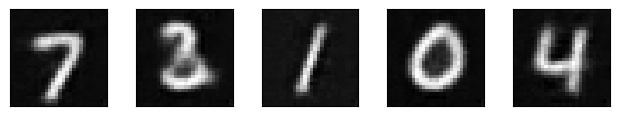

EPOCH 18/50 	 訓練損失：89119.641 	 驗證損失： 2448475.750


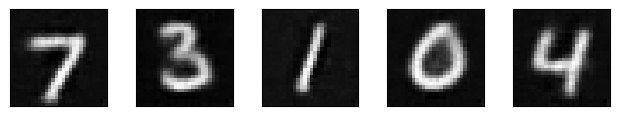

EPOCH 19/50 	 訓練損失：89113.805 	 驗證損失： 2449496.250


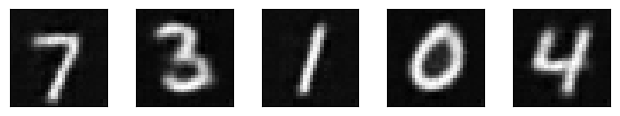

EPOCH 20/50 	 訓練損失：89072.508 	 驗證損失： 2444140.250


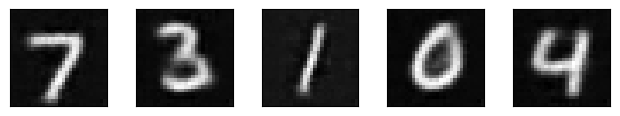

EPOCH 21/50 	 訓練損失：89053.508 	 驗證損失： 2448856.250


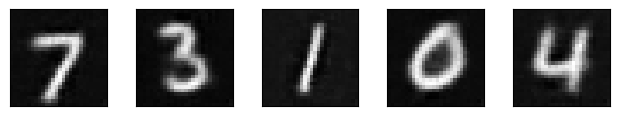

EPOCH 22/50 	 訓練損失：89018.711 	 驗證損失： 2437694.000


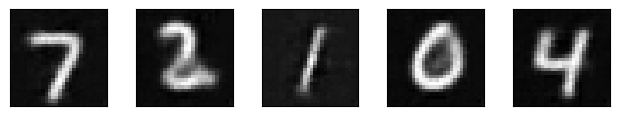

EPOCH 23/50 	 訓練損失：89019.492 	 驗證損失： 2437958.500


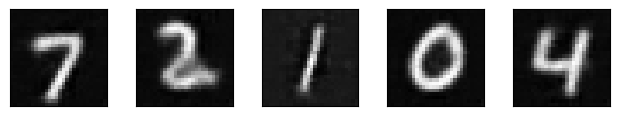

EPOCH 24/50 	 訓練損失：88995.492 	 驗證損失： 2437722.500


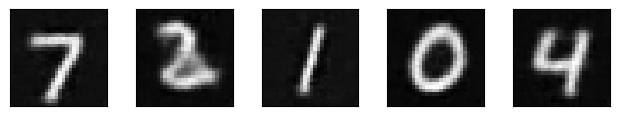

EPOCH 25/50 	 訓練損失：88970.008 	 驗證損失： 2441310.250


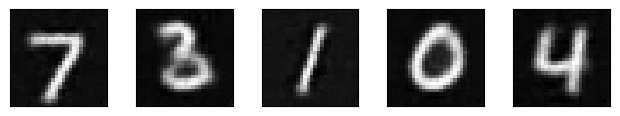

EPOCH 26/50 	 訓練損失：88943.211 	 驗證損失： 2435237.250


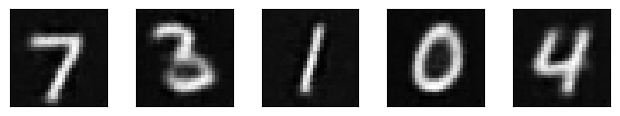

EPOCH 27/50 	 訓練損失：88936.203 	 驗證損失： 2436977.000


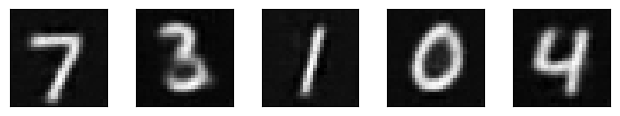

EPOCH 28/50 	 訓練損失：88913.938 	 驗證損失： 2429559.000


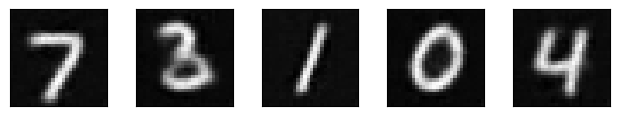

EPOCH 29/50 	 訓練損失：88893.812 	 驗證損失： 2432534.250


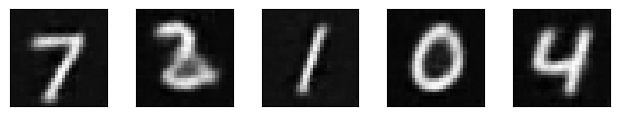

EPOCH 30/50 	 訓練損失：88876.172 	 驗證損失： 2433862.000


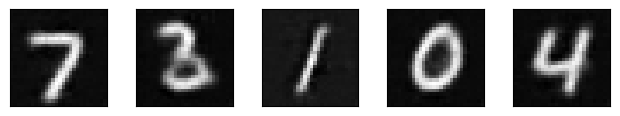

EPOCH 31/50 	 訓練損失：88855.344 	 驗證損失： 2433187.250


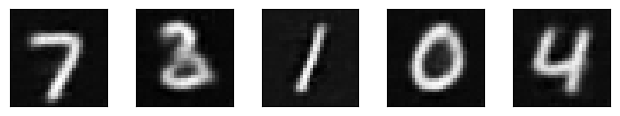

EPOCH 32/50 	 訓練損失：88840.594 	 驗證損失： 2429681.250


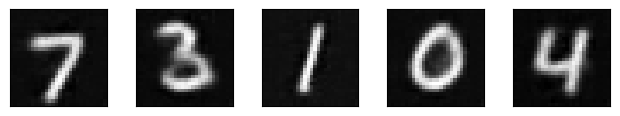

EPOCH 33/50 	 訓練損失：88852.148 	 驗證損失： 2424966.750


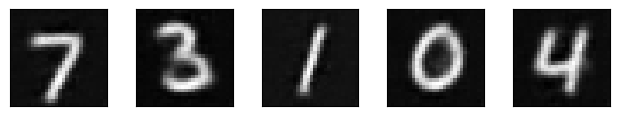

EPOCH 34/50 	 訓練損失：88806.680 	 驗證損失： 2429613.500


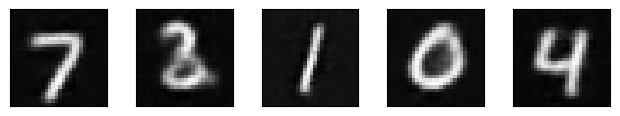

EPOCH 35/50 	 訓練損失：88818.969 	 驗證損失： 2428659.250


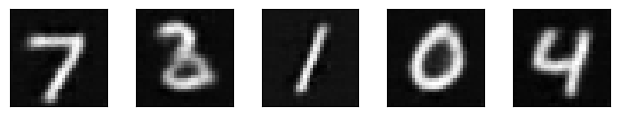

EPOCH 36/50 	 訓練損失：88775.430 	 驗證損失： 2425704.000


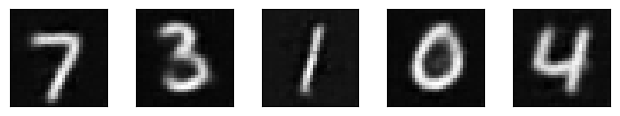

EPOCH 37/50 	 訓練損失：88786.086 	 驗證損失： 2424646.750


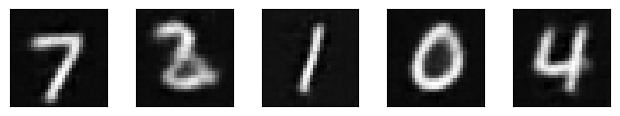

EPOCH 38/50 	 訓練損失：88781.781 	 驗證損失： 2427449.000


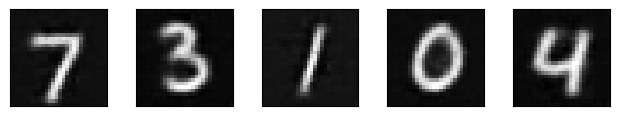

EPOCH 39/50 	 訓練損失：88781.023 	 驗證損失： 2428998.500


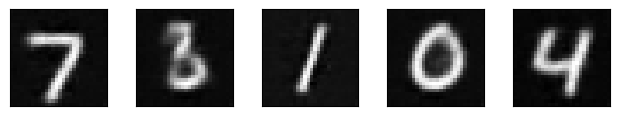

EPOCH 40/50 	 訓練損失：88782.062 	 驗證損失： 2414014.750


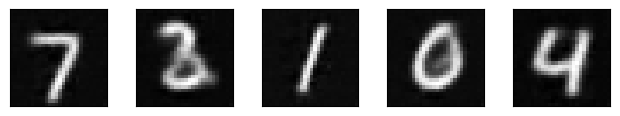

EPOCH 41/50 	 訓練損失：88758.148 	 驗證損失： 2424120.500


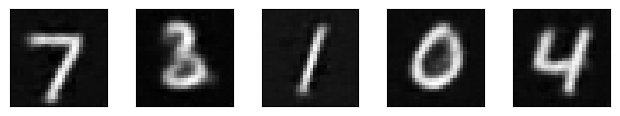

EPOCH 42/50 	 訓練損失：88754.891 	 驗證損失： 2425968.000


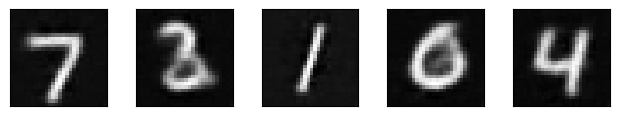

EPOCH 43/50 	 訓練損失：88742.938 	 驗證損失： 2417915.000


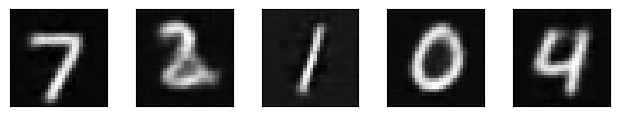

EPOCH 44/50 	 訓練損失：88723.758 	 驗證損失： 2416030.250


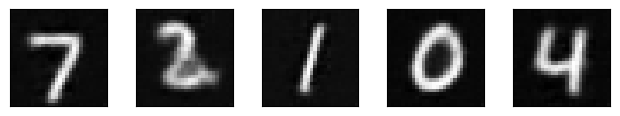

EPOCH 45/50 	 訓練損失：88722.961 	 驗證損失： 2420635.000


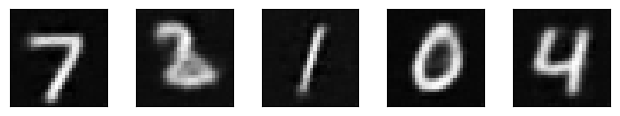

EPOCH 46/50 	 訓練損失：88716.891 	 驗證損失： 2422062.500


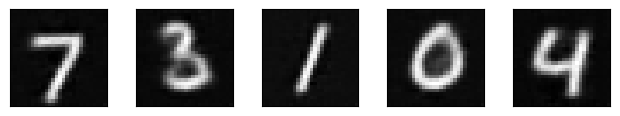

EPOCH 47/50 	 訓練損失：88703.797 	 驗證損失： 2415282.750


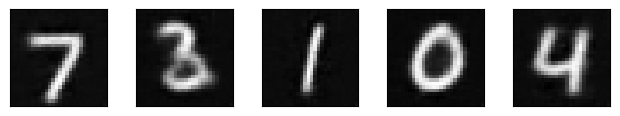

EPOCH 48/50 	 訓練損失：88683.477 	 驗證損失： 2413812.750


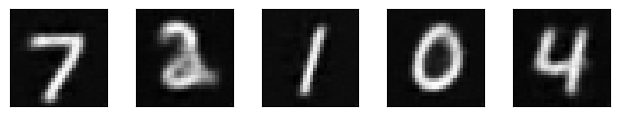

EPOCH 49/50 	 訓練損失：88695.492 	 驗證損失： 2419044.750


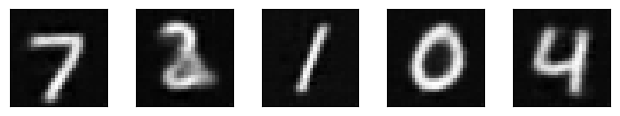

EPOCH 50/50 	 訓練損失：88672.266 	 驗證損失： 2412031.750


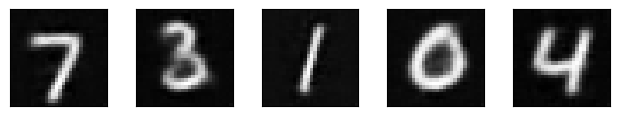

In [15]:
noise_factor = 0.3
num_epochs = 50
history_da = {'train_loss': [], 'val_loss': []}

for epoch in range(num_epochs):
    # print(f'EPOCH {epoch + 1}/{num_epochs}')
    # 訓練
    train_loss = train_epoch_den(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        noise_factor=noise_factor,
    )
    # 驗證
    val_loss = test_epoch_den(
        encoder=encoder,
        decoder=decoder,
        device=device,
        dataloader=valid_loader,
        loss_fn=loss_fn,
        noise_factor=noise_factor,
    )
    # Print Validation loss
    history_da['train_loss'].append(train_loss)
    history_da['val_loss'].append(val_loss)
    print(f'EPOCH {epoch + 1}/{num_epochs} \t 訓練損失：{train_loss:.3f}' + f' \t 驗證損失： {val_loss:.3f}')
    plot_ae_outputs_den(epoch, encoder, decoder, noise_factor=noise_factor)

In [16]:
test_epoch_den(encoder, decoder, device, test_loader, loss_fn).item()

2006089.625

## 使用隨機亂數生成圖像

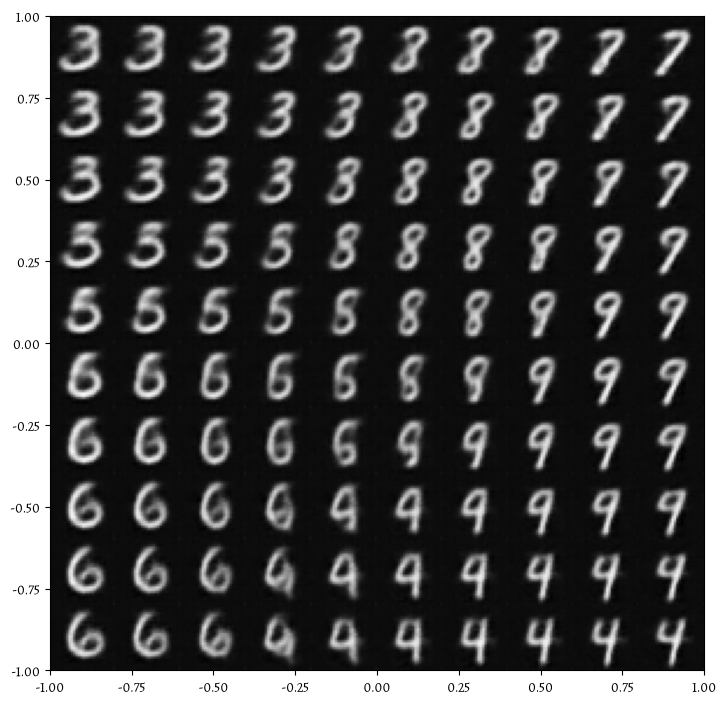

In [17]:
def plot_reconstructed(
    decoder: Decoder, r0: tuple[float, float] = (-5, 10), r1: tuple[float, float] = (-10, 5), n: int = 10
) -> None:
    plt.figure(figsize=(20, 8.5))
    w = 28
    img = np.zeros((n * w, n * w))
    # 隨機亂數
    for i, y in enumerate(np.linspace(*r1, n)):
        for j, x in enumerate(np.linspace(*r0, n)):
            z = torch.Tensor([[x, y], [x, y]]).reshape(-1, 4).to(device)
            # print(z.shape)
            x_hat = decoder(z)
            x_hat = x_hat.reshape(28, 28).to('cpu').detach().numpy()
            img[(n - 1 - i) * w : (n - 1 - i + 1) * w, j * w : (j + 1) * w] = x_hat
    plt.imshow(img, extent=(*r0, *r1), cmap='gist_gray')


plot_reconstructed(decoder, r0=(-1, 1), r1=(-1, 1))

## 觀察模型中間的潛在因子(Latent Factor)，即編碼器的輸出

In [18]:
encoded_sample_list = []
for sample in test_ds:
    img = sample[0].unsqueeze(0).to(device)
    label = sample[1]
    # Encode image
    encoder.eval()
    with torch.no_grad():
        encoded_img = resample(*encoder(img))
    # Append to list
    encoded_img = encoded_img.flatten().cpu().numpy()
    encoded_sample = {f"變數 {i}": enc for i, enc in enumerate(encoded_img)}
    encoded_sample['label'] = label
    encoded_sample_list.append(encoded_sample)

encoded_samples = pd.DataFrame(encoded_sample_list)
encoded_samples

,變數 0,變數 1,變數 2,變數 3,label
0,1.132212,-0.475047,2.085975,1.760395,7
1,-2.182944,0.132459,0.104451,0.172580,2
2,-0.123022,0.670312,2.077475,-1.178128,1
3,-0.297509,0.120149,-1.501493,-0.579778,0
4,1.275415,-1.398560,-0.633188,-1.293593,4
...,...,...,...,...,...
9995,-1.110213,2.021058,1.158320,1.805501,2
9996,-1.811829,0.132115,-0.273279,1.023315,3
9997,1.807065,-0.003153,0.990355,-1.194412,4
9998,1.649207,1.050171,-0.451511,-0.885727,5


In [19]:
fig = px.scatter(encoded_samples, x='變數 0', y='變數 1', color=encoded_samples.label.astype(str), opacity=0.7)
fig

## TSNE 降維

In [20]:
# TSNE 降維
tsne = TSNE(n_components=2)
tsne_results = tsne.fit_transform(encoded_samples.drop(['label'], axis=1))

# 繪圖
fig = px.scatter(
    tsne_results, x=0, y=1, color=encoded_samples.label.astype(str), labels={'0': 'tsne-變數1', '1': 'tsne-變數2'}
)
fig